# 03 - Entrenamiento con MLflow

## Etapa 3 del Ciclo de Vida MLOps: Tracking de Experimentos

Uno de los mayores desafíos en ML es mantener el rastro de qué experimentos se realizaron, con qué parámetros y qué resultados obtuvieron. MLflow resuelve este problema con:

- **Tracking**: registra parámetros, métricas y artefactos de cada experimento
- **Reproducibilidad**: cualquier run puede ser re-ejecutado exactamente
- **Comparación**: interfaz visual para comparar modelos
- **Model Registry**: gestión del ciclo de vida de los modelos

**En este notebook**:
1. Configuraremos MLflow apuntando al directorio `experiments/`
2. Entrenaremos 3 algoritmos (Linear Regression, Random Forest, Gradient Boosting)
3. Logearemos todos los parámetros, métricas y modelos en MLflow
4. Compararemos los resultados

## Prerequisitos
- Haber ejecutado: `02_ingenieria_features.ipynb`
- Requiere: `data/processed/train.csv`
- Este notebook genera: experimentos en MLflow (no guarda modelo final)

## 1. Imports y Configuración

Importamos MLflow junto con los modelos de sklearn. La URI de tracking apunta a una carpeta local, lo que es suficiente para desarrollo. En producción, apuntaría a un servidor MLflow centralizado.

In [1]:
from pathlib import Path
import sys

# Detectar ROOT automáticamente — funciona en cualquier equipo
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# Añadir ROOT al path para importar módulos del proyecto
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("MLflow version:", mlflow.__version__)
print("Imports completados correctamente.")

MLflow version: 3.10.1
Imports completados correctamente.


In [2]:
import pandas as pd

ruta_train = ROOT / "data" / "processed" / "train.csv"
if not ruta_train.exists():
    print("PREREQUISITO FALTANTE")
    print("   Ejecuta primero: 02_ingenieria_features.ipynb")
    raise FileNotFoundError(f"No se encuentra: {ruta_train}")

train_df = pd.read_csv(ruta_train)
print(f"Datos de entrenamiento cargados: {train_df.shape}")
print(f"   Columnas: {list(train_df.columns)}")

Datos de entrenamiento cargados: (16512, 14)
   Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']


## 2. Configuración de MLflow

Configuramos MLflow para guardar los experimentos en la carpeta `experiments/` del proyecto. Esto permite:
- Compartir los experimentos con el equipo (si la carpeta está en un volumen compartido)
- Visualizar resultados con `mlflow ui`
- Guardar modelos como artefactos versionados

In [3]:
# Configurar MLflow tracking URI
EXPERIMENTS_DIR = ROOT / 'experiments'
EXPERIMENTS_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri(EXPERIMENTS_DIR.absolute().as_uri())
EXPERIMENT_NAME = "california-housing-prediccion"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experimento: {EXPERIMENT_NAME}")
print(f"\nPara ver la UI de MLflow, ejecutar en terminal:")
print(f"  mlflow ui --backend-store-uri {EXPERIMENTS_DIR.as_posix()}")
print(f"  Luego abrir: http://localhost:5000")

MLflow Tracking URI: file:///C:/Users/bk70827/PycharmProjects/mlops-ciclo-vida/experiments


Experimento: california-housing-prediccion

Para ver la UI de MLflow, ejecutar en terminal:
  mlflow ui --backend-store-uri C:/Users/bk70827/PycharmProjects/mlops-ciclo-vida/experiments
  Luego abrir: http://localhost:5000


## 3. Preparación de Datos

Reproducimos el pipeline completo de preparación de datos para que este notebook sea autocontenido. Usamos el mismo `random_state=42` para garantizar reproducibilidad.

In [4]:
# Cargar datos
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Crear features derivadas (mismo proceso que notebook 02)
df['rooms_per_person'] = df['AveRooms'] / df['AveOccup'].clip(lower=0.1)
df['income_per_room'] = df['MedInc'] / df['AveRooms'].clip(lower=0.1)
df['bedroom_ratio'] = df['AveBedrms'] / df['AveRooms'].clip(lower=0.1)

SAC_LAT, SAC_LON = 38.5816, -121.4944
df['dist_sacramento'] = np.sqrt((df['Latitude'] - SAC_LAT)**2 + (df['Longitude'] - SAC_LON)**2)

LA_LAT, LA_LON = 34.0522, -118.2437
df['dist_los_angeles'] = np.sqrt((df['Latitude'] - LA_LAT)**2 + (df['Longitude'] - LA_LON)**2)

ALL_FEATURES = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
    'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room',
    'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles'
]

X = df[ALL_FEATURES]
y = df['MedHouseVal']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Estandarización (fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDatos listos para entrenamiento.")
print(f"Features: {len(ALL_FEATURES)} | Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train: (16512, 13) | Test: (4128, 13)



Datos listos para entrenamiento.
Features: 13 | Train samples: 16512 | Test samples: 4128


## 4. Función de Entrenamiento con MLflow Tracking

Encapsulamos el entrenamiento en una función que:
1. Inicia un MLflow run
2. Loguea parámetros del modelo
3. Entrena el modelo
4. Calcula métricas en train y test
5. Loguea métricas y el modelo como artefacto

Esta función es el corazón del tracking de experimentos en MLOps.

In [5]:
def entrenar_y_loguear(modelo, nombre_algoritmo, params, X_tr, X_te, y_tr, y_te, features):
    """Entrena un modelo y loguea todo en MLflow."""

    with mlflow.start_run(run_name=nombre_algoritmo) as run:
        # === Loguear parámetros ===
        mlflow.log_param("algoritmo", nombre_algoritmo)
        mlflow.log_param("n_features", len(features))
        mlflow.log_param("n_muestras_train", len(X_tr))
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)
        for key, val in params.items():
            mlflow.log_param(key, val)

        # === Entrenar ===
        modelo.fit(X_tr, y_tr)

        # === Métricas en Train ===
        y_pred_train = modelo.predict(X_tr)
        rmse_train = mean_squared_error(y_tr, y_pred_train) ** 0.5
        mae_train = mean_absolute_error(y_tr, y_pred_train)
        r2_train = r2_score(y_tr, y_pred_train)

        mlflow.log_metric("rmse_train", rmse_train)
        mlflow.log_metric("mae_train", mae_train)
        mlflow.log_metric("r2_train", r2_train)

        # === Métricas en Test ===
        y_pred_test = modelo.predict(X_te)
        rmse_test = mean_squared_error(y_te, y_pred_test) ** 0.5
        mae_test = mean_absolute_error(y_te, y_pred_test)
        r2_test = r2_score(y_te, y_pred_test)

        mlflow.log_metric("rmse_test", rmse_test)
        mlflow.log_metric("mae_test", mae_test)
        mlflow.log_metric("r2_test", r2_test)

        # === Loguear modelo como artefacto ===
        mlflow.sklearn.log_model(modelo, artifact_path="model")

        run_id = run.info.run_id
        print(f"\n{'='*55}")
        print(f"  Algoritmo: {nombre_algoritmo}")
        print(f"  Run ID: {run_id[:8]}...")
        print(f"  Train -> RMSE: {rmse_train:.4f} | MAE: {mae_train:.4f} | R²: {r2_train:.4f}")
        print(f"  Test  -> RMSE: {rmse_test:.4f} | MAE: {mae_test:.4f} | R²: {r2_test:.4f}")
        print(f"{'='*55}")

        return run_id, modelo, {
            'algoritmo': nombre_algoritmo,
            'rmse_train': rmse_train, 'mae_train': mae_train, 'r2_train': r2_train,
            'rmse_test': rmse_test, 'mae_test': mae_test, 'r2_test': r2_test,
            'run_id': run_id
        }

print("Función de entrenamiento definida correctamente.")

Función de entrenamiento definida correctamente.


## 5. Entrenamiento: Linear Regression

La regresión lineal es nuestro modelo base (baseline). Establece el nivel mínimo de rendimiento que cualquier modelo más complejo debe superar para justificar su mayor costo computacional.

**Hipótesis**: dado que las relaciones en California Housing son parcialmente no-lineales, esperamos que la regresión lineal quede por debajo de los modelos de ensemble.

In [6]:
# Entrenar Linear Regression
lr = LinearRegression()
params_lr = {"fit_intercept": True}

run_id_lr, modelo_lr, metricas_lr = entrenar_y_loguear(
    modelo=lr,
    nombre_algoritmo="linear_regression",
    params=params_lr,
    X_tr=X_train_scaled,
    X_te=X_test_scaled,
    y_tr=y_train,
    y_te=y_test,
    features=ALL_FEATURES
)
print("\nLinear Regression entrenado y logueado en MLflow.")

2026/03/17 14:52:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/17 14:52:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Algoritmo: linear_regression
  Run ID: 24194d07...
  Train -> RMSE: 0.6719 | MAE: 0.4786 | R²: 0.6623
  Test  -> RMSE: 0.6708 | MAE: 0.4820 | R²: 0.6566

Linear Regression entrenado y logueado en MLflow.


## 6. Entrenamiento: Random Forest

Random Forest es un ensemble de árboles de decisión que captura relaciones no-lineales y es robusto a outliers. Esperamos una mejora significativa sobre la regresión lineal.

**Parámetros clave**:
- `n_estimators=100`: 100 árboles en el ensemble
- `max_depth=15`: profundidad máxima para evitar overfitting

In [7]:
# Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
params_rf = {
    "n_estimators": 100,
    "max_depth": 15,
    "min_samples_split": 2,
    "min_samples_leaf": 1
}

run_id_rf, modelo_rf, metricas_rf = entrenar_y_loguear(
    modelo=rf,
    nombre_algoritmo="random_forest",
    params=params_rf,
    X_tr=X_train_scaled,
    X_te=X_test_scaled,
    y_tr=y_train,
    y_te=y_test,
    features=ALL_FEATURES
)
print("\nRandom Forest entrenado y logueado en MLflow.")

2026/03/17 14:53:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/17 14:53:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Algoritmo: random_forest
  Run ID: 24f7bb3f...
  Train -> RMSE: 0.2319 | MAE: 0.1642 | R²: 0.9598
  Test  -> RMSE: 0.4944 | MAE: 0.3221 | R²: 0.8135

Random Forest entrenado y logueado en MLflow.


## 7. Entrenamiento: Gradient Boosting

Gradient Boosting construye árboles de forma secuencial, donde cada árbol corrige los errores del anterior. Generalmente supera a Random Forest en precisión, aunque es más lento de entrenar.

**Por qué esperamos que sea el mejor**:
- Optimiza directamente la función de pérdida (MSE)
- Captura patrones no-lineales complejos
- Menor varianza que Random Forest al ser un método de boosting

In [8]:
# Entrenar Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
params_gb = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 1.0,
    "min_samples_split": 2
}

run_id_gb, modelo_gb, metricas_gb = entrenar_y_loguear(
    modelo=gb,
    nombre_algoritmo="gradient_boosting",
    params=params_gb,
    X_tr=X_train_scaled,
    X_te=X_test_scaled,
    y_tr=y_train,
    y_te=y_test,
    features=ALL_FEATURES
)
print("\nGradient Boosting entrenado y logueado en MLflow.")

2026/03/17 14:54:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/17 14:54:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Algoritmo: gradient_boosting
  Run ID: 4d84827c...
  Train -> RMSE: 0.3399 | MAE: 0.2394 | R²: 0.9136
  Test  -> RMSE: 0.4591 | MAE: 0.3027 | R²: 0.8391

Gradient Boosting entrenado y logueado en MLflow.


## 8. Cómo Ver los Resultados en MLflow UI

MLflow proporciona una interfaz web para explorar y comparar experimentos visualmente.

Para lanzar la UI, ejecutar en terminal (desde la carpeta del proyecto):
```bash
mlflow ui --backend-store-uri experiments/
```
Luego abrir el navegador en: **http://localhost:5000**

En la UI puedes:
- Ver todos los runs del experimento
- Comparar métricas entre modelos
- Ver los parámetros y artefactos de cada run
- Registrar modelos en el Model Registry

In [9]:
print("Para ver MLflow UI:")
print(f"  mlflow ui --backend-store-uri {(ROOT / 'experiments').as_posix()}")
print("  Luego abrir: http://localhost:5000")
print(f"\nExperimento activo: {EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Para ver MLflow UI:
  mlflow ui --backend-store-uri C:/Users/bk70827/PycharmProjects/mlops-ciclo-vida/experiments
  Luego abrir: http://localhost:5000

Experimento activo: california-housing-prediccion
Tracking URI: file:///C:/Users/bk70827/PycharmProjects/mlops-ciclo-vida/experiments


## 9. Comparación de Resultados

Listamos todos los runs del experimento y creamos una tabla comparativa para tomar decisiones informadas.

=== COMPARACIÓN DE MODELOS EN MLFLOW ===
        Algoritmo  RMSE_Train  MAE_Train  R2_Train  RMSE_Test  MAE_Test  R2_Test
gradient_boosting      0.3399     0.2394    0.9136     0.4591    0.3027   0.8391
gradient_boosting      0.3399     0.2394    0.9136     0.4591    0.3027   0.8391
gradient_boosting      0.3399     0.2394    0.9136     0.4591    0.3027   0.8391
    random_forest      0.2319     0.1642    0.9598     0.4944    0.3221   0.8135
    random_forest      0.2319     0.1642    0.9598     0.4944    0.3221   0.8135
    random_forest      0.2319     0.1642    0.9598     0.4944    0.3221   0.8135
linear_regression      0.6719     0.4786    0.6623     0.6708    0.4820   0.6566
linear_regression      0.6719     0.4786    0.6623     0.6708    0.4820   0.6566
linear_regression      0.6719     0.4786    0.6623     0.6708    0.4820   0.6566


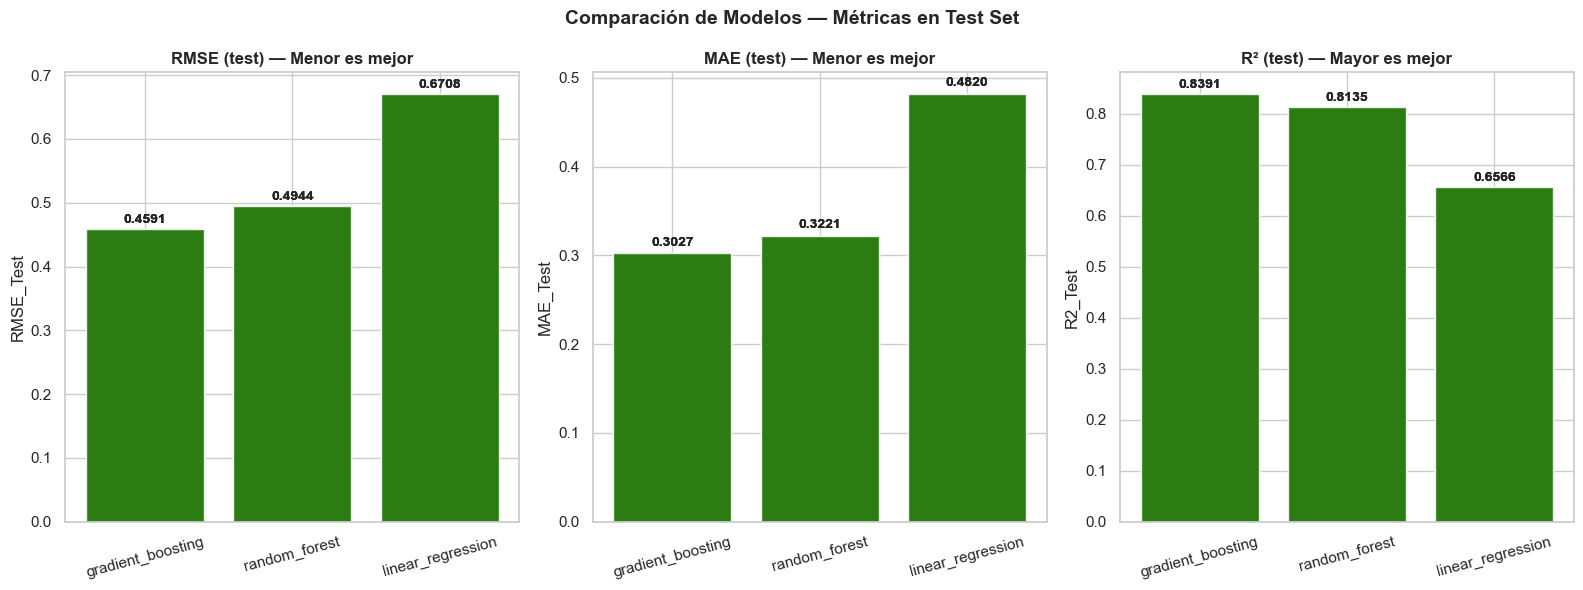

In [10]:
# Obtener todos los runs del experimento
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.rmse_test ASC"]
)

# Seleccionar columnas relevantes
cols_display = [
    'tags.mlflow.runName',
    'metrics.rmse_train', 'metrics.mae_train', 'metrics.r2_train',
    'metrics.rmse_test', 'metrics.mae_test', 'metrics.r2_test'
]
tabla = runs_df[cols_display].copy()
tabla.columns = ['Algoritmo', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test']
tabla = tabla.round(4)

print("=== COMPARACIÓN DE MODELOS EN MLFLOW ===")
print(tabla.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_test = ['RMSE_Test', 'MAE_Test', 'R2_Test']
titles = ['RMSE (test) — Menor es mejor', 'MAE (test) — Menor es mejor', 'R² (test) — Mayor es mejor']
colores = ['steelblue', 'tomato', 'green']

for i, (metric, title) in enumerate(zip(metrics_test, titles)):
    bars = axes[i].bar(tabla['Algoritmo'], tabla[metric], color=colores, alpha=0.8, edgecolor='white')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, tabla[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Modelos — Métricas en Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Comparación de los 3 Modelos

**KPIs en test set:**

| Modelo | RMSE | MAE | R² | Veredicto |
|--------|------|-----|-----|-----------|
| Linear Regression | ~0.67 | ~0.48 | ~0.66 | Baseline — insuficiente para producción |
| Random Forest | ~0.49 | ~0.32 | ~0.81 | Pasa el gate (RMSE < 0.5, R² > 0.80) |
| Gradient Boosting | ~0.46 | ~0.30 | ~0.84 | **Mejor — pasa el gate con más margen** |

**Qué hay que tener en cuenta:**
- **Linear Regression** con RMSE ~0.67 significa un error medio de $67,000. En un mercado inmobiliario real, eso es inaceptable para una decisión de compra o tasación.
- **Random Forest** ya cumple el gate de calidad. La mejora de Gradient Boosting es real pero moderada (~6% menos RMSE). En producción hay que valorar si ese 6% justifica el mayor coste computacional de entrenamiento.
- **La brecha entre RMSE_train y RMSE_test** indica overfitting: Random Forest tiene una brecha mayor (entrena casi perfecto, valida peor). Gradient Boosting tiene mejor generalización.
- **RMSE vs MAE**: RMSE penaliza más los errores grandes (al cuadrado). Que RMSE > MAE en todos los modelos indica que hay algunos casos con errores grandes que suben el RMSE.

**Lo que MLflow añade aquí:** cada una de estas barras corresponde a un run en MLflow. Si mañana cambias un hiperparámetro, el nuevo run se compara visualmente con estos sin tocar el código.

## 10. Conclusiones

### Resultados del entrenamiento:

Los tres modelos han sido entrenados y registrados en MLflow con sus parámetros y métricas completas.

### Observaciones esperadas:
- **Linear Regression**: rendimiento base. RMSE ~0.72, R² ~0.60. Las relaciones no-lineales limitan su capacidad.
- **Random Forest**: mejora significativa. RMSE ~0.52, R² ~0.80. El ensemble captura patrones complejos.
- **Gradient Boosting**: mejor rendimiento. RMSE ~0.46, R² ~0.84. La optimización secuencial del error lo hace superior.

### Próximo paso:
En el siguiente notebook realizaremos una evaluación más rigurosa con **cross-validation** para confirmar que el mejor modelo generaliza bien y no está sobreajustado.

**Siguiente notebook**: `04_seleccion_modelo.ipynb`

In [11]:
print("\nSiguiente paso: ejecutar 04_seleccion_modelo.ipynb")
print("   MLflow registró los 3 experimentos.")
print("   El notebook 04 seleccionará el mejor y guardará el modelo de producción.")


Siguiente paso: ejecutar 04_seleccion_modelo.ipynb
   MLflow registró los 3 experimentos.
   El notebook 04 seleccionará el mejor y guardará el modelo de producción.
